## Exercício
Um dataset sintético contendo alguns exemplos de diferentes formas básicas é criado. Em seguida, implemente um modelo convolucional que classifique o formato na imagem.

### Dados

In [1]:
import numpy as np
import cv2
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# Parâmetros
image_size = 64
num_examples = 2000
label_names = ['circulo', 'triangulo', 'linha_horizontal', 'quadrado', 'linha_vertical']
num_classes = len(label_names)
data_dir = "data/custom"

In [3]:
# Função para gerar uma imagem de uma determinada classe
def generate_image(label):
    image = np.zeros((image_size, image_size, 3), dtype=np.uint8)
    color = (np.random.randint(256), np.random.randint(256), np.random.randint(256))

    if label == 'circulo':
        center = (np.random.randint(10, image_size-10), np.random.randint(10, image_size-10))
        radius = np.random.randint(5, 10)
        cv2.circle(image, center, radius, color, -1)

    elif label == 'triangulo':
        side_length = np.random.randint(10, 20)
        height = int(np.sqrt(3)/2 * side_length)
        center = (np.random.randint(side_length//2, image_size-side_length//2),
                  np.random.randint(height//2, image_size-height//2))
        pts = np.array([[center[0], center[1] - 2*height//3],
                        [center[0] - side_length//2, center[1] + height//3],
                        [center[0] + side_length//2, center[1] + height//3]], np.int32)
        pts = pts.reshape((-1, 1, 2))
        cv2.fillPoly(image, [pts], color)

    elif label == 'linha_horizontal':
        y = np.random.randint(5, image_size-5)
        thickness = np.random.randint(1, 3)
        cv2.line(image, (0, y), (image_size, y), color, thickness)

    elif label == 'quadrado':
        top_left = (np.random.randint(10, image_size-10), np.random.randint(10, image_size-10))
        size = np.random.randint(5, 10)
        bottom_right = (top_left[0] + size, top_left[1] + size)
        cv2.rectangle(image, top_left, bottom_right, color, -1)

    elif label == 'linha_vertical':
        x = np.random.randint(5, image_size-5)
        thickness = np.random.randint(1, 3)
        cv2.line(image, (x, 0), (x, image_size), color, thickness)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

In [4]:
def show_image(image):
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

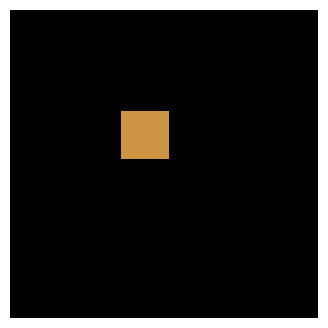

In [5]:
show_image(generate_image('quadrado'))

In [6]:
# Cria pastas para cada classe
for label in label_names:
    os.makedirs(os.path.join(data_dir, label), exist_ok=True)

# Geração e salvamento das imagens
for i in tqdm(range(num_examples)):
    label = np.random.choice(label_names)
    image = generate_image(label)

    im = Image.fromarray(image)
    path = os.path.join(data_dir, str(label), f"{i}.png")
    im.save(path)

print(f"{num_examples} imagens salvas em {data_dir}/[0..{num_classes-1}]/")

100%|██████████| 2000/2000 [00:01<00:00, 1721.99it/s]

2000 imagens salvas em data/custom/[0..4]/


### CNN

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import datasets, transforms

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # ajuste conforme os dados
])

synthetic_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Dividindo o dataset em conjuntos de treino e teste
trainset = Subset(synthetic_dataset, range(1800))
valset = Subset(synthetic_dataset, range(1800, 2000))

# Criando DataLoaders para os subsets
train_loader = DataLoader(trainset, batch_size=32, shuffle=True)
val_loader = DataLoader(valset, batch_size=32, shuffle=True)

In [9]:
x, y = next(iter(train_loader))
print(f"Tamanho do batch: {x.shape}, Rótulos: {y.shape}")

Tamanho do batch: torch.Size([32, 3, 64, 64]), Rótulos: torch.Size([32])


In [10]:
def train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=5):
    history = {
        'train_losses': [],
        'val_losses': [],
        'train_accuracies': [],
        'val_accuracies': []
    }

    for epoch in range(num_epochs):
        # Treinamento
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for i, data in tqdm(enumerate(trainloader, 0), total=len(trainloader)):
            inputs, labels = data

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct / total
        history['train_losses'].append(train_loss)
        history['train_accuracies'].append(train_acc)
        print(f'Epoch {epoch+1}, Train Loss: {train_loss:.3f}, Train Accuracy: {train_acc:.2f}%')

        # Validação
        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data in valloader:
                inputs, labels = data
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(valloader)
        val_acc = 100 * correct / total
        history['val_losses'].append(val_loss)
        history['val_accuracies'].append(val_acc)
        print(f'Epoch {epoch+1}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_acc:.2f}%')

    print('Treinamento concluído')
    return history


def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_losses'], label='Train')
    ax1.plot(history['val_losses'], label='Validation')
    ax1.set_title('Loss')
    ax1.legend()

    ax2.plot(history['train_accuracies'], label='Train')
    ax2.plot(history['val_accuracies'], label='Validation')
    ax2.set_title('Accuracy')
    ax2.legend()

    plt.show()


def test_model(model, testloader):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Acurácia da rede na base de teste: {100 * correct / total:.2f}%')

In [11]:
# entrada 3,64,64
# saida 5

class CNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        #camada convolucional 1
        self.conv1 = nn.Conv2d(3,16,3)
        #camada convolucional 2
        self.conv2 = nn.Conv2d(16,32,3)
        #camada linear 1
        self.fc1 = nn.Linear(32 * 14 * 14, 64)
        #camada linear 2
        self.fc2 = nn.Linear(64,num_classes)


    def forward(self, x):
       # CNN
       #camada de ativação
        x = F.relu(self.conv1(x))
        #camada de max pooling
        x = F.max_pool2d(x, 2, 2)
        #camada de ativação
        x = F.relu(self.conv2(x))
        #camada de max pooling
        x = F.max_pool2d(x, 2, 2)

        # Flatten
        x = x.view(-1, 32 * 14 * 14)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

input = torch.randn(32, 3, 64, 64)

model = CNN()

model(input).shape

torch.Size([32, 5])

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
# Treinamento
history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

100%|██████████| 57/57 [00:03<00:00, 16.68it/s]


Epoch 1, Train Loss: 0.767, Train Accuracy: 64.61%
Epoch 1, Val Loss: 0.210, Val Accuracy: 99.00%


100%|██████████| 57/57 [00:03<00:00, 17.42it/s]


Epoch 2, Train Loss: 0.069, Train Accuracy: 98.56%
Epoch 2, Val Loss: 0.034, Val Accuracy: 99.50%


100%|██████████| 57/57 [00:04<00:00, 11.96it/s]


Epoch 3, Train Loss: 0.016, Train Accuracy: 99.89%
Epoch 3, Val Loss: 0.020, Val Accuracy: 99.50%


100%|██████████| 57/57 [00:04<00:00, 11.73it/s]


Epoch 4, Train Loss: 0.012, Train Accuracy: 99.72%
Epoch 4, Val Loss: 0.032, Val Accuracy: 99.50%


100%|██████████| 57/57 [00:02<00:00, 19.46it/s]


Epoch 5, Train Loss: 0.008, Train Accuracy: 99.94%
Epoch 5, Val Loss: 0.033, Val Accuracy: 99.00%
Treinamento concluído


In [14]:
# Teste
test_model(model, val_loader)

Acurácia da rede na base de teste: 99.00%


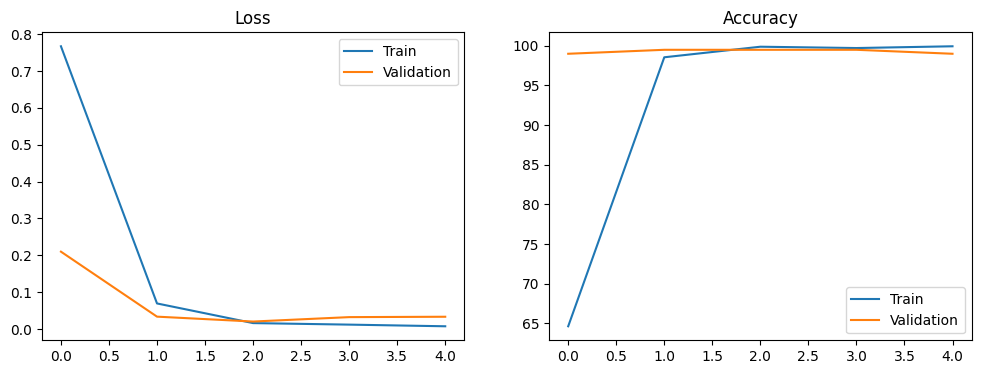

In [15]:
plot_history(history)

Observação:
* Este cenário aonde a função de custo de validação é maior do que a de treino e a acurácia de treino é maior do que a validação pode indicar overfitting. Com isso, podemos criar um novo modelo aplicando uma regularização do tipo dropout

In [29]:
# entrada 3,64,64
# saida 5

class CNN_model(nn.Module):
    def __init__(self, num_classes=5, initialize_weights=True, dropout=0.2):
        super().__init__()
        #camada convolucional 1
        self.conv1 = nn.Conv2d(3,8,5)
        #camada convolucional 2
        self.conv2 = nn.Conv2d(8,16,5)
        #camada linear 1
        self.fc1 = nn.Linear(16 * 13 * 13, 64)
        #camada linear 2
        self.fc2 = nn.Linear(64,num_classes)
        self.dropout = nn.Dropout(dropout)

        if initialize_weights:
            self._initialize_weights()


    def forward(self, x):
       # CNN
       #camada de ativação
        x = F.relu(self.conv1(x))
        #camada de max pooling
        x = F.max_pool2d(x, 2, 2)
        #camada de ativação
        x = F.relu(self.conv2(x))
        #camada de max pooling
        x = F.max_pool2d(x, 2, 2)

        # Flatten
        x = x.view(-1, 16 * 13 * 13)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

input = torch.randn(32, 3, 64, 64)

modelo = CNN_model(initialize_weights=False,dropout=0.0)

modelo(input).shape

torch.Size([32, 5])

In [30]:
criterion = nn.CrossEntropyLoss()
#optimizer = optim.SGD(modelo.parameters(), lr=0.01, momentum=0.9)
optimizer = optim.Adam(modelo.parameters(), lr=0.01)

In [31]:
# Treinamento
history = train_model(modelo, train_loader, val_loader, criterion, optimizer, num_epochs=10)

100%|██████████| 57/57 [00:02<00:00, 26.66it/s]


Epoch 1, Train Loss: 0.928, Train Accuracy: 58.89%
Epoch 1, Val Loss: 1.320, Val Accuracy: 0.00%


100%|██████████| 57/57 [00:02<00:00, 23.72it/s]


Epoch 2, Train Loss: 0.611, Train Accuracy: 72.00%
Epoch 2, Val Loss: 0.982, Val Accuracy: 0.00%


100%|██████████| 57/57 [00:02<00:00, 27.49it/s]


...

Epoch 8, Train Loss: 0.110, Train Accuracy: 97.17%
Epoch 8, Val Loss: 0.126, Val Accuracy: 99.50%


100%|██████████| 57/57 [00:02<00:00, 26.38it/s]


Epoch 9, Train Loss: 0.035, Train Accuracy: 99.33%
Epoch 9, Val Loss: 0.080, Val Accuracy: 99.50%


100%|██████████| 57/57 [00:02<00:00, 26.70it/s]


Epoch 10, Train Loss: 0.008, Train Accuracy: 99.78%
Epoch 10, Val Loss: 0.008, Val Accuracy: 100.00%
Treinamento concluído


In [32]:
# Teste
test_model(modelo, val_loader)

Acurácia da rede na base de teste: 100.00%


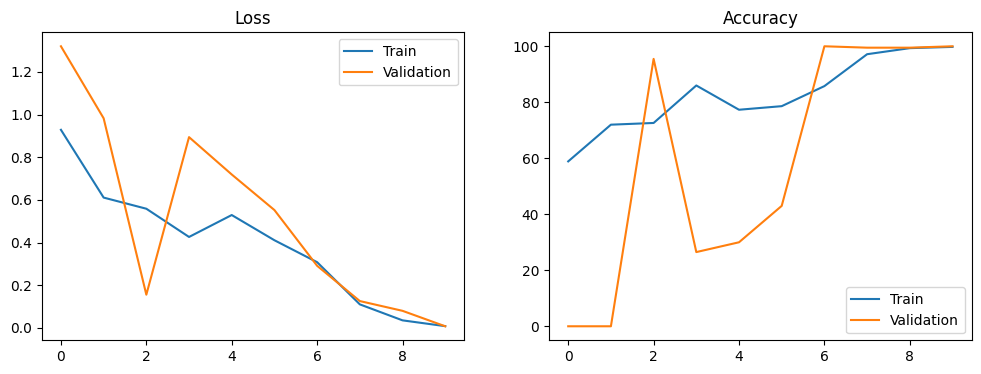

In [33]:
plot_history(history)

Observação:
* Apliquei algumas modificações sendo elas:
    -  regularização com dropout igual a 0 e a inicialização dos pesos falsa
    - número de épocas igual a 10
    - tamanho do kernel igual a 5

Com estas alterações tivemos uma melhora na acurácia e a convergência entre a função de custo de treino e validação.